In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import matplotlib.pyplot as plt

train_df = pd.read_csv('train_data.csv')

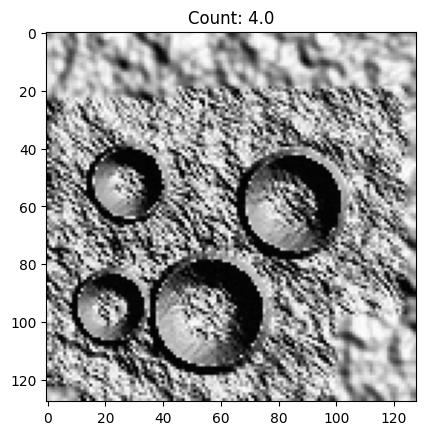

In [2]:
def load_example(id):
    path = f'images/{id:04d}.png'
    img = np.array(Image.open(path))
    plt.imshow(img, cmap='grey')
    count = train_df.iloc[id]['count']
    plt.title(f'Count: {count}')
    res = 4
    new_img = np.zeros((128//res, 128//res))
    for i in range(0, 128, res):
        for j in range(0, 128, res):
            new_img[i//res,j//res] = np.var(img[i:i+res, j:j+res])

    # plt.imshow(new_img)

load_example(5)

In [6]:
IMAGE_DIR = "./images"
CSV_PATH = "train_data.csv"

IMG_SIZE = 128
BATCH_SIZE = 32
TRAIN_RATIO = 0.95

class AgeDataset(Dataset):
    def __init__(self, csv_path, image_dir, transform=None):
        self.df = pd.read_csv(csv_path)

        self.image_ids = self.df.iloc[:, 0].values
        self.ages = self.df.iloc[:, 2].values.astype("float32")

        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]

        img_name = f"{int(img_id):04d}.png"
        img_path = os.path.join(self.image_dir, img_name)

        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        age = torch.tensor(self.ages[idx], dtype=torch.float32)

        return image, age


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

dataset = AgeDataset(
    csv_path=CSV_PATH,
    image_dir=IMAGE_DIR,
    transform=transform
)

train_size = int(TRAIN_RATIO * len(dataset))
val_size = len(dataset) - train_size


train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [19]:
from torch import nn
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(True),

    nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(True),

    nn.MaxPool2d(2),

    nn.Conv2d(32, 32, kernel_size=3, padding=1, groups=32, bias=False),
    nn.Conv2d(32, 64, kernel_size=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),

    nn.MaxPool2d(2),

    nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
    nn.Conv2d(64, 128, kernel_size=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),

    nn.AdaptiveAvgPool2d((1,1)),
    nn.Flatten(),
    nn.Dropout(0.1),
    nn.Linear(128, 1)
)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
val_criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 20

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for images, ages in train_loader:
        images = images.to(device, dtype=torch.float32)
        ages = ages.to(device, dtype=torch.float32).view(-1, 1)
        optimizer.zero_grad()

        preds = model(images)
        if preds.dim() == 1:
            preds = preds.view(-1, 1)

        loss = criterion(preds, ages)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, ages in val_loader:
            images = images.to(device, dtype=torch.float32)
            ages = ages.to(device, dtype=torch.float32).view(-1, 1)

            preds = model(images)
            if preds.dim() == 1:
                preds = preds.view(-1, 1)

            loss = val_criterion(preds, ages)
            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch [1/20] Train Loss: 0.3489 | Val Loss: 0.3747
Epoch [2/20] Train Loss: 0.2566 | Val Loss: 0.3298
Epoch [3/20] Train Loss: 0.2080 | Val Loss: 0.4708
Epoch [4/20] Train Loss: 0.1766 | Val Loss: 0.2392
Epoch [5/20] Train Loss: 0.1417 | Val Loss: 0.4074
Epoch [6/20] Train Loss: 0.1268 | Val Loss: 0.2329
Epoch [7/20] Train Loss: 0.1194 | Val Loss: 0.1780
Epoch [8/20] Train Loss: 0.1164 | Val Loss: 0.2328
Epoch [9/20] Train Loss: 0.1596 | Val Loss: 0.3986
Epoch [10/20] Train Loss: 0.1134 | Val Loss: 0.1660


KeyboardInterrupt: 